# Credit Card Fraud Detection

## Project Overview

This project focuses on detecting fraudulent credit card transactions using machine learning.

The dataset contains transaction-related features along with a target variable, `Class`, where:
- `0` represents a legitimate transaction
- `1` represents a fraudulent transaction

The main objective is to build and evaluate machine learning models that can identify fraudulent transactions while handling the highly imbalanced nature of the dataset.

## Import Required Libraries

We import the libraries required for data manipulation, visualization, preprocessing, machine learning, and model evaluation.

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

## Load the Dataset

The complete credit card transaction dataset is loaded for analysis and model development.


In [ ]:

credit_card_data = pd.read_csv("creditcard.csv")

In [4]:
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Credit Card Details are very sensitive details, thus should not be exposed . Thus, the dataset provider has converted all the features through principal component analysis method, converting all the features into these numerical values. Here , Amount Column is in USD and Class Column is composed of 2 labels (0 for Legit Transaction and 1 for Fraudulent Transaction). Time is in seconds.

In [5]:
credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [6]:
credit_card_data.shape

(284807, 31)

## Exploratory Data Analysis

We examine the structure, statistical properties, and data quality of the dataset before building the machine learning models.

In [29]:
# Dataset information
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [30]:
# Checking the number of missing values in each column

credit_card_data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

This shows that we dont have any missing values.


In [31]:
# Distribution of legit transactions and fraudulent transactions
credit_card_data['Class'].value_counts()

0    284315
1       492
Name: Class, dtype: int64

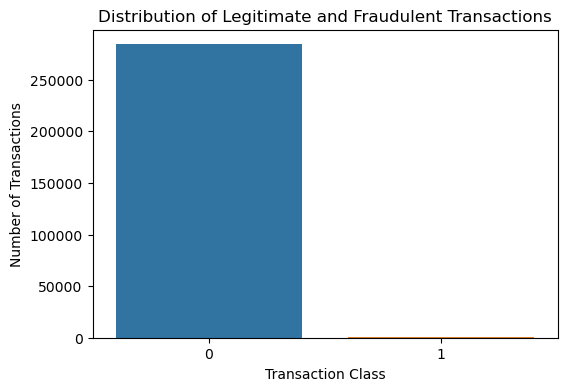

In [32]:
# Visualize the class imbalance.
plt.figure(figsize=(6, 4))

sns.countplot(
    x="Class",
    data=credit_card_data
)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

In [33]:
class_distribution = credit_card_data["Class"].value_counts(
    normalize=True
) * 100

print(class_distribution)

0    99.827251
1     0.172749
Name: Class, dtype: float64


## Analyze Class Distribution

The dataset is highly imbalanced, with fraudulent transactions representing only a small fraction of total transactions.

Understanding this imbalance is important because accuracy alone may not provide a reliable measure of fraud detection performance.

## Separate Features and Target

The dataset is divided into:
- Features (`X`): transaction attributes used by the models
- Target (`Y`): the `Class` variable indicating whether a transaction is legitimate or fraudulent

In [ ]:

X = credit_card_data.drop("Class", axis=1)

Y = credit_card_data["Class"]

In [35]:
print("Features:", X.shape)
print("Target:", Y.shape)

Features: (284807, 30)
Target: (284807,)


## Split the Dataset

The dataset is divided into training and testing sets using stratified sampling.

The split is performed before addressing class imbalance so that the test set retains the original real-world class distribution.

In [ ]:

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

In [37]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (227845, 30)
Testing set: (56962, 30)


In [38]:
print("\nTraining class distribution:")
print(Y_train.value_counts())

print("\nTesting class distribution:")
print(Y_test.value_counts())


Training class distribution:
0    227451
1       394
Name: Class, dtype: int64

Testing class distribution:
0    56864
1       98
Name: Class, dtype: int64


## Scale the Features

Feature scaling is applied to ensure that numerical features are on comparable scales.

The scaler is fitted only on the training data and then applied to both the training and testing data.

In [ ]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Logistic Regression

Logistic Regression is used as the baseline classification model.

Because the dataset is highly imbalanced, `class_weight="balanced"` is used to give greater importance to the minority fraud class.

In [ ]:

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [41]:
# Train
logistic_model.fit(
    X_train_scaled,
    Y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [42]:
# Predict
y_pred = logistic_model.predict(X_test_scaled)

y_prob = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

## Logistic Regression Evaluation

The Logistic Regression model is evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC.

A confusion matrix is also used to understand the number of correctly and incorrectly classified transactions.

In [ ]:

print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [44]:
print("Accuracy:",
      accuracy_score(Y_test, y_pred))

print("Precision:",
      precision_score(Y_test, y_pred))

print("Recall:",
      recall_score(Y_test, y_pred))

print("F1 Score:",
      f1_score(Y_test, y_pred))

print("ROC-AUC:",
      roc_auc_score(Y_test, y_prob))

print("PR-AUC:",
      average_precision_score(Y_test, y_prob))

Accuracy: 0.9755451002422668
Precision: 0.061016949152542375
Recall: 0.9183673469387755
F1 Score: 0.11443102352193261
ROC-AUC: 0.9720881652464024
PR-AUC: 0.718934567134695


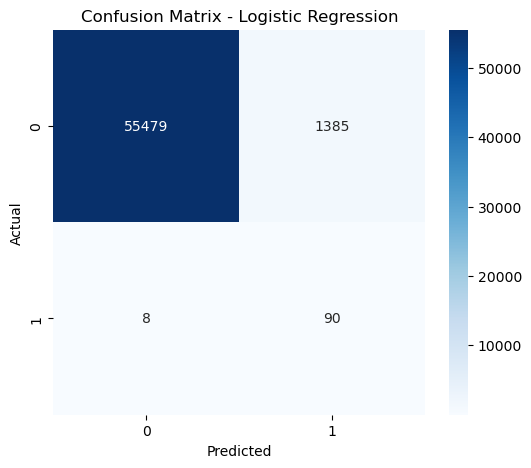

In [45]:
# Confusion matrix
cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

## Random Forest Classifier

Random Forest is used as a second classification model to compare its performance with Logistic Regression.

Since the dataset is highly imbalanced, class weights are used to give more importance to fraudulent transactions.

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, Y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [ ]:
# Make predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

## Random Forest Evaluation

The Random Forest model is evaluated using the same metrics as Logistic Regression so that the two models can be compared consistently.

A confusion matrix is also analyzed to examine false positives and false negatives.

In [ ]:

print("Random Forest Results")
print("---------------------")

print("Accuracy:", accuracy_score(Y_test, rf_pred))
print("Precision:", precision_score(Y_test, rf_pred))
print("Recall:", recall_score(Y_test, rf_pred))
print("F1 Score:", f1_score(Y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(Y_test, rf_prob))
print("PR-AUC:", average_precision_score(Y_test, rf_prob))


Random Forest Results
---------------------
Accuracy: 0.9995084442259752
Precision: 0.9605263157894737
Recall: 0.7448979591836735
F1 Score: 0.839080459770115
ROC-AUC: 0.952908497036969
PR-AUC: 0.8541999432510914


In [27]:
# Classification report
print(classification_report(Y_test, rf_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



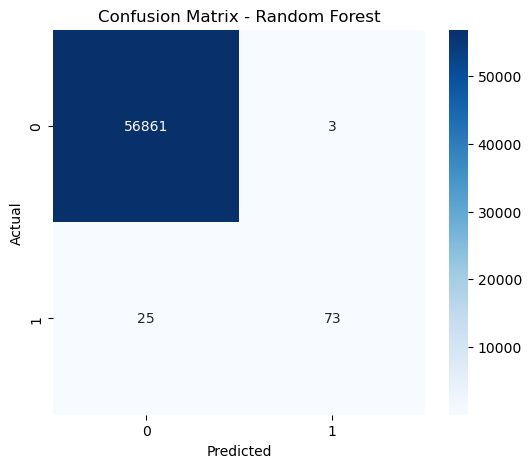

In [28]:
# Confusion Matrix
cm_rf = confusion_matrix(Y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

## Model Comparison

We compare Logistic Regression and Random Forest using multiple evaluation metrics.

Since the dataset is highly imbalanced, precision, recall, F1-score, ROC-AUC and PR-AUC are considered alongside accuracy.

In [46]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(Y_test, y_pred),
        accuracy_score(Y_test, rf_pred)
    ],
    "Precision": [
        precision_score(Y_test, y_pred),
        precision_score(Y_test, rf_pred)
    ],
    "Recall": [
        recall_score(Y_test, y_pred),
        recall_score(Y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(Y_test, y_pred),
        f1_score(Y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(Y_test, y_prob),
        roc_auc_score(Y_test, rf_prob)
    ],
    "PR-AUC": [
        average_precision_score(Y_test, y_prob),
        average_precision_score(Y_test, rf_prob)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.975545,0.061017,0.918367,0.114431,0.972088,0.718935
1,Random Forest,0.999508,0.960526,0.744898,0.839080,0.952908,0.854200
